# 07 — Logit Regularizado (L1 / L2 / ElasticNet)

**Extensión del Logit básico con penalización.** Permite shrinkage de coeficientes
y selección automática de variables (L1/Lasso).

Referencia de clase: `modelos R/logit/1 - Logistica y regularización.R`
(usa `glmnet` con `cv.glmnet` para selección de lambda)

**Flujo:**
1. `LogisticRegressionCV` para L1, L2 y ElasticNet (CV AUC)
2. Comparación de los tres sobre CV AUC vs C
3. Mejor modelo global → métricas completas
4. Plot de coeficientes del mejor modelo
5. Predicciones test

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, confusion_matrix, f1_score, roc_curve

print('Imports OK')

Imports OK


In [2]:
SEED = 42
np.random.seed(SEED)

BASE_DIR = Path('../../')
DATA_DIR = BASE_DIR / 'data/processed'

matplotlib.rcParams.update({'figure.figsize': (9, 6), 'font.size': 12,
                            'axes.spines.top': False, 'axes.spines.right': False})

In [3]:
df       = pd.read_parquet(DATA_DIR / 'features_train.parquet')
df_test  = pd.read_parquet(DATA_DIR / 'features_test.parquet')

feature_cols = [c for c in df.columns if c not in ('SK_ID_CURR', 'TARGET')]

X_raw       = df[feature_cols].values
y           = df['TARGET'].values
X_test_raw  = df_test[feature_cols].values
sk_ids_test = df_test['SK_ID_CURR'].values

print(f'Train: {X_raw.shape}  | Default rate: {y.mean():.2%}')

Train: (307511, 30)  | Default rate: 8.07%


In [4]:
imputer = SimpleImputer(strategy='median')
scaler  = StandardScaler()

X_imp    = imputer.fit_transform(X_raw)
X_scaled = scaler.fit_transform(X_imp)

X_test_scaled = scaler.transform(imputer.transform(X_test_raw))

print(f'X_scaled: {X_scaled.shape} — NaNs: {np.isnan(X_scaled).sum()}')

X_scaled: (307511, 30) — NaNs: 0


In [5]:
def compute_metrics(y_true, y_prob, threshold=0.5, label='Model'):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    auc  = roc_auc_score(y_true, y_prob)
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    return dict(Model=label, AUC=round(auc,4),
                N=len(y_true), P=int(y_pred.sum()),
                TP=int(tp), TN=int(tn), FP=int(fp), FN=int(fn),
                Recall=round(rec,4), Precision=round(prec,4), F1=round(f1,4))

def plot_roc_curve(y_true, y_prob, label, color, ax, title='ROC Curve'):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{label} (AUC = {auc:.4f})')
    ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(title); ax.legend()
    return ax

print('Funciones definidas ✓')

Funciones definidas ✓


## 1. Búsqueda de C — L1 (Lasso)

Equivalente a `glmnet(alpha=1)` con `cv.glmnet()` en R.

In [6]:
# C = 1 / lambda en sklearn (C grande = poca regularización)
Cs = np.logspace(-4, 2, 20)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print('Ajustando Logit L1 (Lasso)...')
lr_l1 = LogisticRegressionCV(
    Cs=Cs,
    cv=skf,
    penalty='l1',
    solver='saga',
    scoring='roc_auc',
    class_weight='balanced',
    max_iter=2000,
    n_jobs=-1,
    random_state=SEED
)
lr_l1.fit(X_scaled, y)

best_C_l1   = lr_l1.C_[0]
cv_aucs_l1  = lr_l1.scores_[1].mean(axis=0)  # shape (n_Cs,)
best_auc_l1 = cv_aucs_l1.max()

print(f'Mejor C (L1): {best_C_l1:.6f} | CV AUC: {best_auc_l1:.4f}')
print(f'Coeficientes != 0: {(lr_l1.coef_[0] != 0).sum()} / {len(feature_cols)}')

Ajustando Logit L1 (Lasso)...
Mejor C (L1): 23.357215 | CV AUC: 0.7498
Coeficientes != 0: 30 / 30


## 2. Búsqueda de C — L2 (Ridge)

In [7]:
print('Ajustando Logit L2 (Ridge)...')
lr_l2 = LogisticRegressionCV(
    Cs=Cs,
    cv=skf,
    penalty='l2',
    solver='saga',
    scoring='roc_auc',
    class_weight='balanced',
    max_iter=2000,
    n_jobs=-1,
    random_state=SEED
)
lr_l2.fit(X_scaled, y)

best_C_l2   = lr_l2.C_[0]
cv_aucs_l2  = lr_l2.scores_[1].mean(axis=0)
best_auc_l2 = cv_aucs_l2.max()

print(f'Mejor C (L2): {best_C_l2:.6f} | CV AUC: {best_auc_l2:.4f}')

Ajustando Logit L2 (Ridge)...
Mejor C (L2): 0.001833 | CV AUC: 0.7498


## 3. Búsqueda C × l1_ratio — ElasticNet

Generalización de L1/L2. En R: `glmnet(alpha=0.5)` con `cv.glmnet`.

In [8]:
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]
en_results = []

print('Ajustando ElasticNet (grid l1_ratio × C)...')
for ratio in l1_ratios:
    lr_en = LogisticRegressionCV(
        Cs=Cs,
        cv=skf,
        penalty='elasticnet',
        l1_ratios=[ratio],
        solver='saga',
        scoring='roc_auc',
        class_weight='balanced',
        max_iter=2000,
        n_jobs=-1,
        random_state=SEED
    )
    lr_en.fit(X_scaled, y)
    auc_cv = lr_en.scores_[1].mean(axis=0).max()
    best_c = lr_en.C_[0]
    print(f'  l1_ratio={ratio:.1f} | best C={best_c:.5f} | CV AUC={auc_cv:.4f}')
    en_results.append({'l1_ratio': ratio, 'best_C': best_c, 'cv_auc': auc_cv,
                       'model': lr_en, 'cv_aucs': lr_en.scores_[1].mean(axis=0)})

best_en = max(en_results, key=lambda x: x['cv_auc'])
lr_best_en = best_en['model']
print(f'\nMejor ElasticNet: l1_ratio={best_en["l1_ratio"]} | CV AUC={best_en["cv_auc"]:.4f}')

Ajustando ElasticNet (grid l1_ratio × C)...
  l1_ratio=0.1 | best C=0.14384 | CV AUC=0.7498
  l1_ratio=0.3 | best C=48.32930 | CV AUC=0.7498
  l1_ratio=0.5 | best C=23.35721 | CV AUC=0.7498
  l1_ratio=0.7 | best C=23.35721 | CV AUC=0.7498
  l1_ratio=0.9 | best C=23.35721 | CV AUC=0.7498

Mejor ElasticNet: l1_ratio=0.1 | CV AUC=0.7498


## 4. Comparación L1 / L2 / ElasticNet

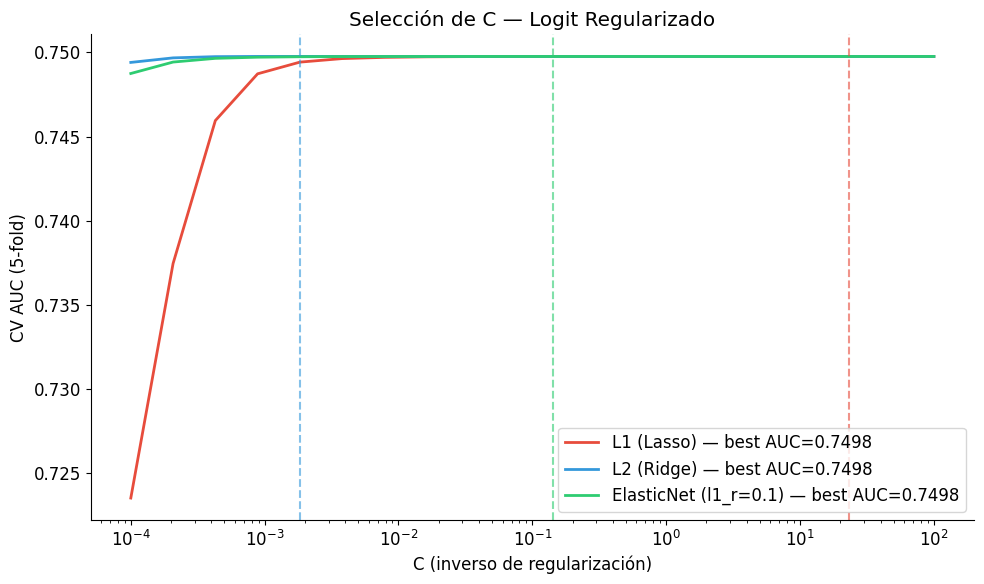

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.semilogx(Cs, cv_aucs_l1, color='#e74c3c', lw=2, label=f'L1 (Lasso) — best AUC={best_auc_l1:.4f}')
ax.semilogx(Cs, cv_aucs_l2, color='#3498db', lw=2, label=f'L2 (Ridge) — best AUC={best_auc_l2:.4f}')
ax.semilogx(Cs, best_en['cv_aucs'], color='#2ecc71', lw=2,
            label=f'ElasticNet (l1_r={best_en["l1_ratio"]}) — best AUC={best_en["cv_auc"]:.4f}')

ax.axvline(best_C_l1, color='#e74c3c', ls='--', alpha=0.6)
ax.axvline(best_C_l2, color='#3498db', ls='--', alpha=0.6)
ax.axvline(best_en['best_C'], color='#2ecc71', ls='--', alpha=0.6)

ax.set_xlabel('C (inverso de regularización)')
ax.set_ylabel('CV AUC (5-fold)')
ax.set_title('Selección de C — Logit Regularizado')
ax.legend()
plt.tight_layout()
plt.show()


In [10]:
compare = pd.DataFrame([
    {'Modelo': 'L1 (Lasso)',    'CV_AUC': round(best_auc_l1, 4), 'best_C': round(best_C_l1, 5),
     'Coef_nonzero': int((lr_l1.coef_[0] != 0).sum())},
    {'Modelo': 'L2 (Ridge)',    'CV_AUC': round(best_auc_l2, 4), 'best_C': round(best_C_l2, 5),
     'Coef_nonzero': int((lr_l2.coef_[0] != 0).sum())},
    {'Modelo': f'ElasticNet (l1={best_en["l1_ratio"]})', 'CV_AUC': round(best_en['cv_auc'], 4),
     'best_C': round(best_en['best_C'], 5),
     'Coef_nonzero': int((lr_best_en.coef_[0] != 0).sum())},
]).set_index('Modelo')

display(compare)
best_model_name = compare['CV_AUC'].idxmax()
print(f'\nMejor modelo: {best_model_name}')

,CV_AUC,best_C,Coef_nonzero
Modelo,,,
L1 (Lasso),0.7498,23.35721,30
L2 (Ridge),0.7498,0.00183,30
ElasticNet (l1=0.1),0.7498,0.14384,30



Mejor modelo: L1 (Lasso)


## 5. Modelo Final — Métricas sobre Train Completo

In [11]:
# Seleccionar el mejor modelo
model_map = {
    'L1 (Lasso)': lr_l1,
    'L2 (Ridge)': lr_l2,
    f'ElasticNet (l1={best_en["l1_ratio"]})': lr_best_en
}
best_lr = model_map[best_model_name]

y_prob_train = best_lr.predict_proba(X_scaled)[:, 1]
metrics = compute_metrics(y, y_prob_train, threshold=0.5, label=best_model_name)

print('=' * 60)
print(f'LOGIT REGULARIZADO ({best_model_name}) — MÉTRICAS')
print('=' * 60)
for k, v in metrics.items():
    if k != 'Model':
        print(f'  {k:<12}: {v}')
print('=' * 60)

display(pd.DataFrame([metrics]).set_index('Model'))

LOGIT REGULARIZADO (L1 (Lasso)) — MÉTRICAS
  AUC         : 0.75
  N           : 307511
  P           : 102660
  TP          : 16716
  TN          : 196742
  FP          : 85944
  FN          : 8109
  Recall      : 0.6734
  Precision   : 0.1628
  F1          : 0.2622


,AUC,N,P,TP,TN,FP,FN,Recall,Precision,F1
Model,,,,,,,,,,
L1 (Lasso),0.75,307511,102660,16716,196742,85944,8109,0.6734,0.1628,0.2622


## 6. Curva ROC — Comparación

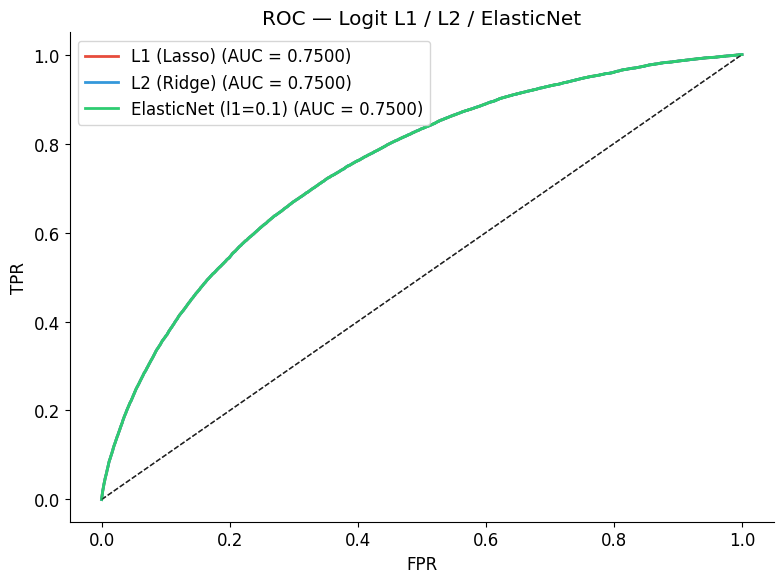

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
colors_roc = ['#e74c3c', '#3498db', '#2ecc71']
for (name, mdl), col in zip(model_map.items(), colors_roc):
    prob = mdl.predict_proba(X_scaled)[:, 1]
    plot_roc_curve(y, prob, label=name, color=col, ax=ax,
                   title='ROC — Logit L1 / L2 / ElasticNet')

plt.tight_layout()
plt.show()


## 7. Coeficientes del Mejor Modelo

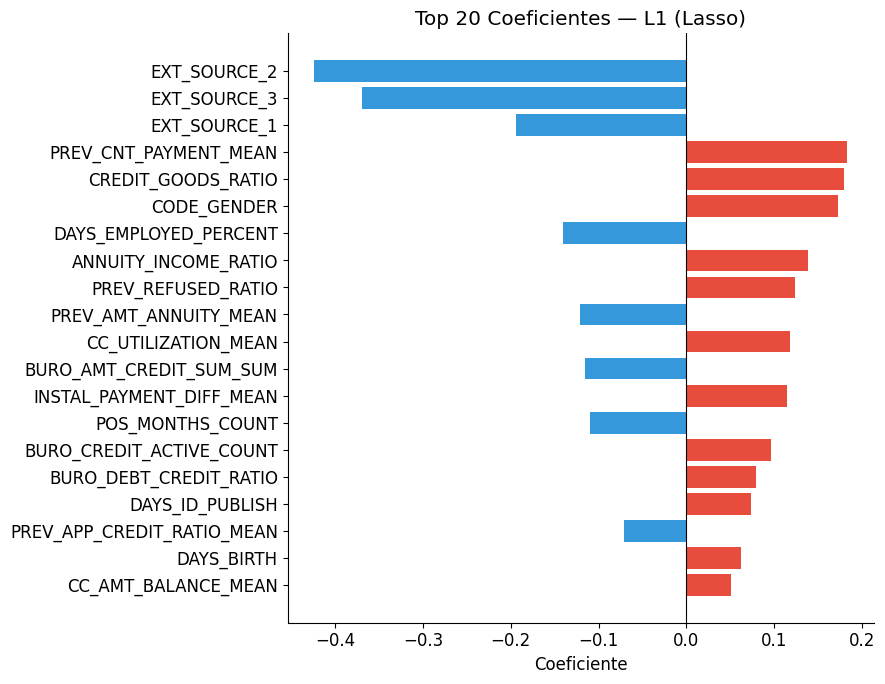

In [13]:
coef_vals = best_lr.coef_[0]
coef_df = pd.DataFrame({'Feature': feature_cols, 'Coef': coef_vals})
coef_df = coef_df[coef_df['Coef'] != 0].reindex(
    coef_df[coef_df['Coef'] != 0]['Coef'].abs().sort_values(ascending=False).index
).head(20)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#e74c3c' if c > 0 else '#3498db' for c in coef_df['Coef']]
ax.barh(coef_df['Feature'][::-1], coef_df['Coef'][::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coeficiente')
ax.set_title(f'Top 20 Coeficientes — {best_model_name}')
plt.tight_layout()
plt.show()


## 8. Predicciones Test

In [14]:
y_test_prob = best_lr.predict_proba(X_test_scaled)[:, 1]
submission  = pd.DataFrame({'SK_ID_CURR': sk_ids_test, 'TARGET': y_test_prob})
out_path = DATA_DIR / 'submission_07_logit_reg.csv'
submission.to_csv(out_path, index=False)

print(f'Predicciones guardadas: {out_path}')
print(f'Score medio predicho: {y_test_prob.mean():.4f}')
display(submission.head())

Predicciones guardadas: ..\..\data\processed\submission_07_logit_reg.csv
Score medio predicho: 0.4257


,SK_ID_CURR,TARGET
0,100001,0.394508
1,100005,0.678109
2,100013,0.301197
3,100028,0.269323
4,100038,0.606434


## Kaggle Submission — AUC Test (Public Leaderboard)

Envía el CSV a `home-credit-default-risk` y recupera el AUC del Public LB (~30% del test).
Usa la Python API (`KaggleApi`) directamente — polling cada 10 s, máx 5 min.

> **Límite**: 5 submissions/día.


In [15]:
from kaggle import KaggleApi
import time

COMPETITION = 'home-credit-default-risk'
_sub_path   = DATA_DIR / 'submission_07_logit_reg.csv'
_msg = f"07_logit_regularized | train={metrics["AUC"]:.4f} | {best_model_name}"

def _as_str(x):
    return '' if x is None else str(x)

def _get_score(api, comp, file_name, message, poll=10, timeout=300):
    """Poll until public_score appears on the matching submission."""
    start = time.time()
    while time.time() - start < timeout:
        subs = api.competition_submissions(comp)
        matched = next(
            (s for s in subs
             if _as_str(getattr(s, 'file_name', None)) == file_name
             and _as_str(getattr(s, 'description', None)) == message),
            subs[0] if subs else None
        )
        if matched:
            pub     = _as_str(getattr(matched, 'public_score',  None))
            status  = _as_str(getattr(matched, 'status',        None))
            elapsed = int(time.time() - start)
            print(f'  [{elapsed:>3}s] status={status!r}  public_score={pub!r}')
            if pub and pub.lower() not in ('', 'none', 'null', '-'):
                priv = _as_str(getattr(matched, 'private_score', None))
                return float(pub), (float(priv) if priv and priv.lower() not in ('','none','null','-') else None)
        time.sleep(poll)
    return None, None

_api = KaggleApi()
_api.authenticate()

print(f'Enviando: {_msg}')
_api.competition_submit(file_name=str(_sub_path), message=_msg, competition=COMPETITION)
print('Esperando scoring (poll 10 s / máx 5 min)...')

public_auc, private_auc = _get_score(_api, COMPETITION, _sub_path.name, _msg)
print(f'\nAUC test  Public  LB : {public_auc}')
print(f'AUC test  Private LB : {private_auc}')

Enviando: 07_logit_regularized | train=0.7500 | L1 (Lasso)


100%|██████████| 1.27M/1.27M [00:01<00:00, 827kB/s] 


Esperando scoring (poll 10 s / máx 5 min)...
  [  0s] status='SubmissionStatus.PENDING'  public_score=''
  [ 10s] status='SubmissionStatus.COMPLETE'  public_score='0.74984'

AUC test  Public  LB : 0.74984
AUC test  Private LB : 0.73514
